# 02 — Exploratory Data Analysis & Class Distribution
## Skin Cancer Classification – HAM10000 Dataset

### Objective

This notebook explores the HAM10000 dataset through visual and statistical analysis.

The goals are to:
- understand class imbalance
- inspect image quality and variability
- analyze metadata distributions
- visualize representative samples
- identify potential modeling challenges

## 1. Imports

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image
from collections import Counter

## 2. Load Metadata

In [3]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"

METADATA_PATH = RAW_DIR / "HAM10000_metadata.csv"

metadata = pd.read_csv(METADATA_PATH)

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## 3. Diagnosis Mapping

In [4]:
dx_mapping = {
    "akiec": "Actinic keratoses",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

metadata["diagnosis_full"] = metadata["dx"].map(dx_mapping)

## 4. Class Distribution analysis

### Class counts

In [5]:
class_counts = (
    metadata["diagnosis_full"]
    .value_counts()
    .sort_values(ascending=False)
)

class_counts

diagnosis_full
Melanocytic nevi                 6705
Melanoma                         1113
Benign keratosis-like lesions    1099
Basal cell carcinoma              514
Actinic keratoses                 327
Vascular lesions                  142
Dermatofibroma                    115
Name: count, dtype: int64

### Class percentages

In [6]:
class_percentages = (
    metadata["diagnosis_full"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

class_percentages

diagnosis_full
Melanocytic nevi                 66.95
Melanoma                         11.11
Benign keratosis-like lesions    10.97
Basal cell carcinoma              5.13
Actinic keratoses                 3.27
Vascular lesions                  1.42
Dermatofibroma                    1.15
Name: proportion, dtype: float64

### Class Distribution Visualisation

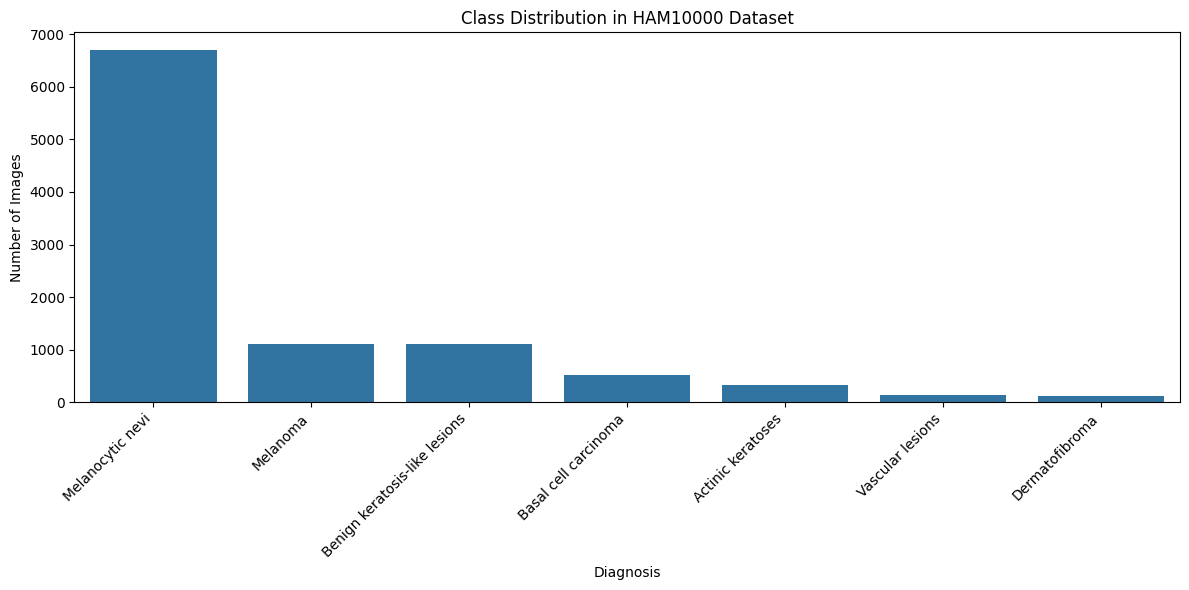

In [7]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Class Distribution in HAM10000 Dataset")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Images")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 5. Class Imbalance Discussion

### Observations

The dataset is highly imbalanced.

Melanocytic nevi largely dominate the dataset, while some classes such as dermatofibroma and vascular lesions contain very few samples.

Potential consequences:
- biased model predictions
- poor minority class recall
- misleading accuracy scores

Potential mitigation strategies:
- class weighting
- oversampling
- targeted augmentation
- focal loss

## 6. Age Distribution

In [8]:
metadata["age"].describe()

count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64

### Histogram

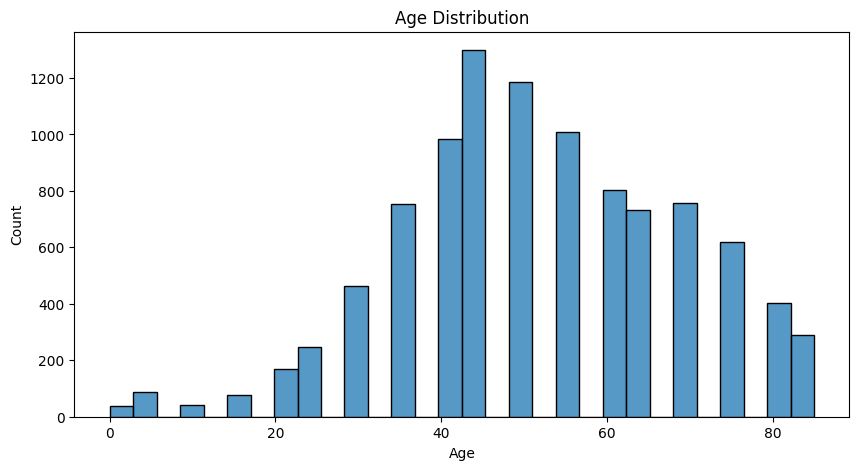

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(
    metadata["age"].dropna(),
    bins=30
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

## 7. Sex Distribution

In [10]:
metadata["sex"].value_counts(dropna=False)

sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

### Visualisation

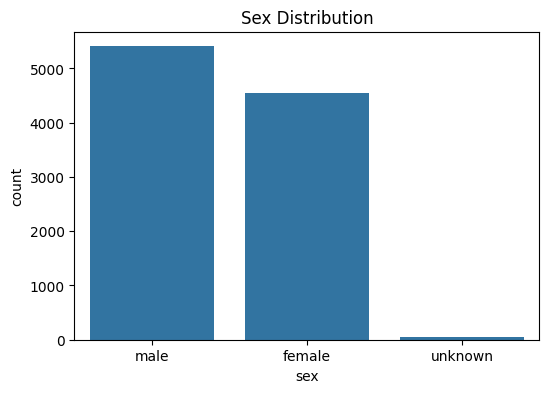

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=metadata,
    x="sex"
)

plt.title("Sex Distribution")

plt.show()

## 9. Lesion localization Analysis

In [12]:
localization_counts = metadata["localization"].value_counts()

localization_counts

localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64

### Visualisation

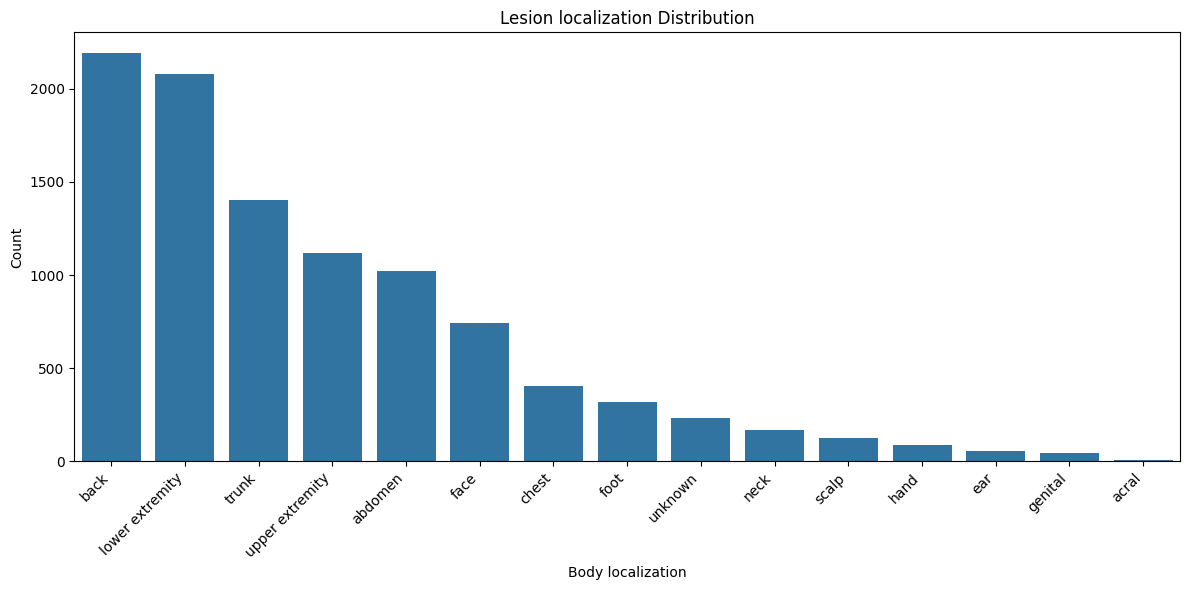

In [13]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=localization_counts.index,
    y=localization_counts.values
)

plt.title("Lesion localization Distribution")
plt.xlabel("Body localization")
plt.ylabel("Count")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 9. Sample Images per Class

### Image Classes

In [14]:
IMAGE_DIR_1 = RAW_DIR / "HAM10000_images_part_1"
IMAGE_DIR_2 = RAW_DIR / "HAM10000_images_part_2"

image_paths = {}

for image_dir in [IMAGE_DIR_1, IMAGE_DIR_2]:
    for image_path in image_dir.glob("*.jpg"):
        image_paths[image_path.stem] = image_path

metadata["image_path"] = metadata["image_id"].map(image_paths)

### Display Samples

In [15]:
def display_samples(df, diagnosis, n=5):
    
    samples = (
        df[df["diagnosis_full"] == diagnosis]
        .sample(n, random_state=42)
    )
    
    plt.figure(figsize=(15, 4))
    
    for i, (_, row) in enumerate(samples.iterrows()):
        
        image = Image.open(row["image_path"])
        
        plt.subplot(1, n, i + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(row["dx"])
    
    plt.suptitle(diagnosis)
    plt.tight_layout()
    plt.show()

### Run Visualisation

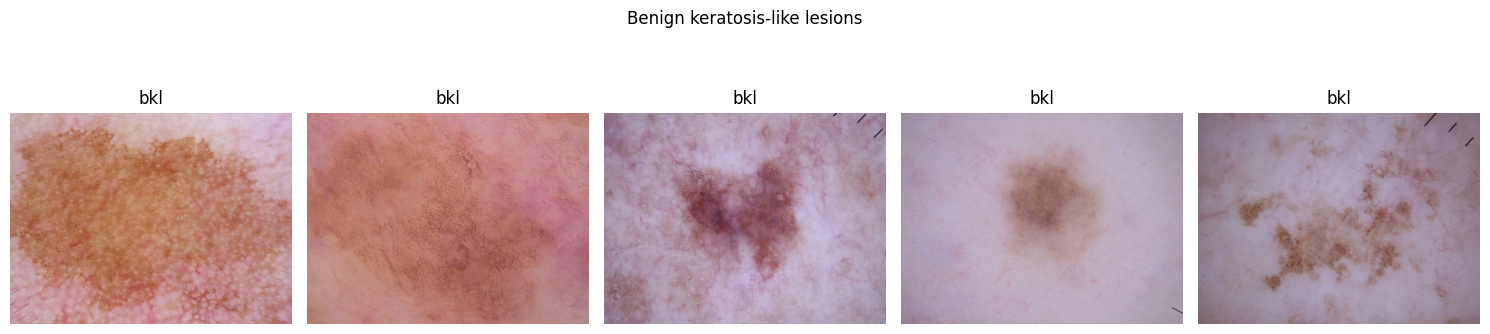

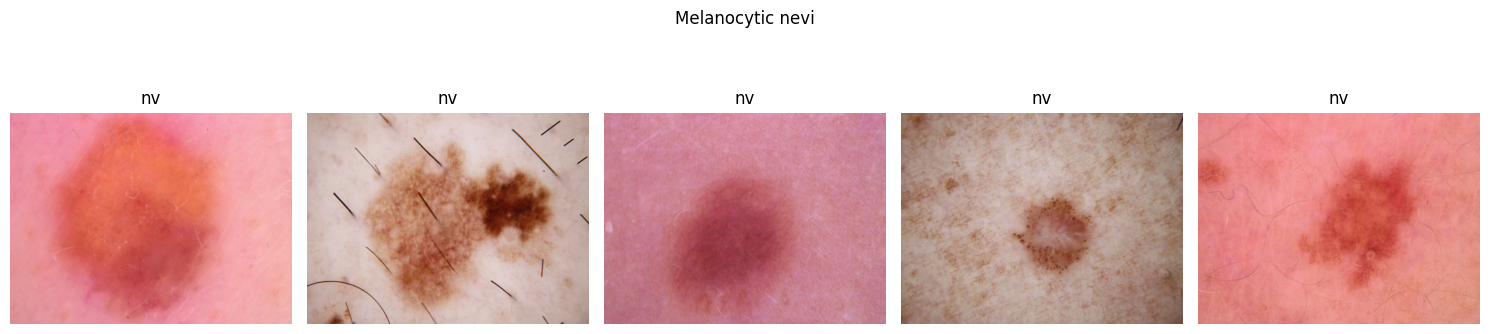

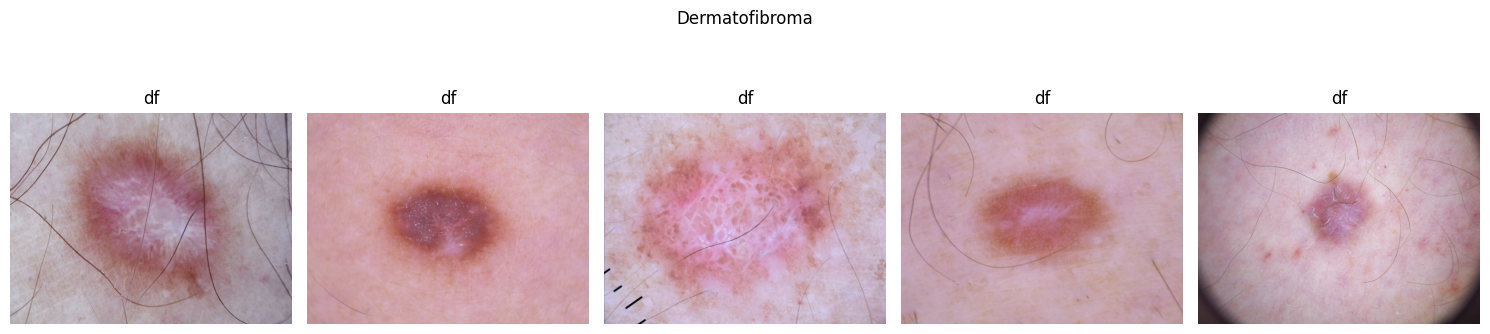

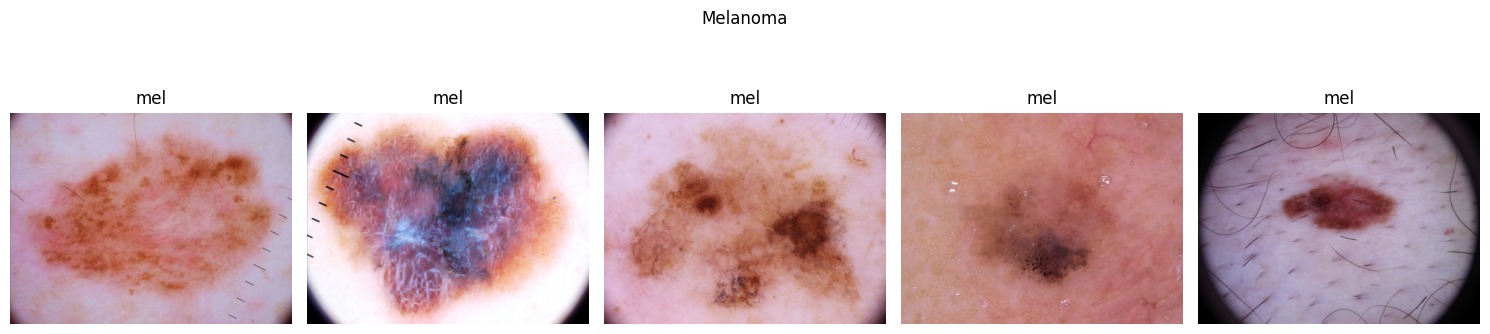

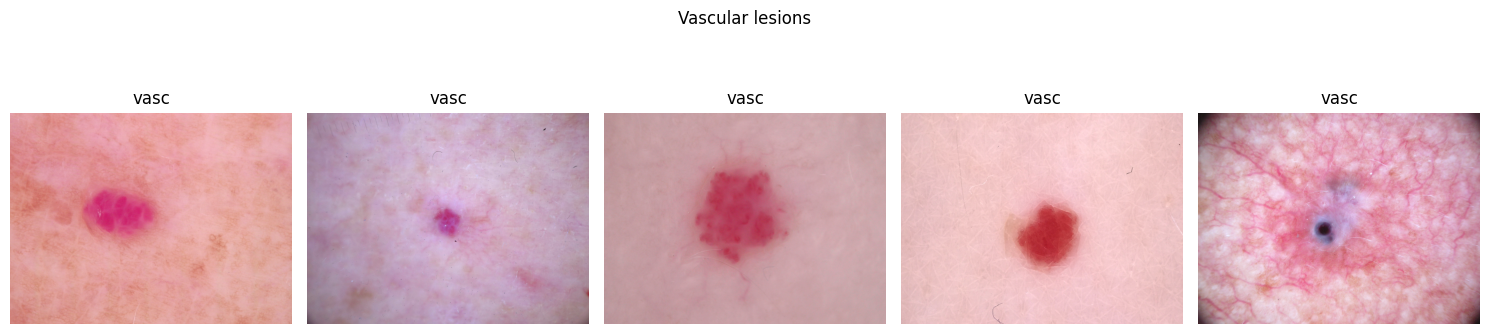

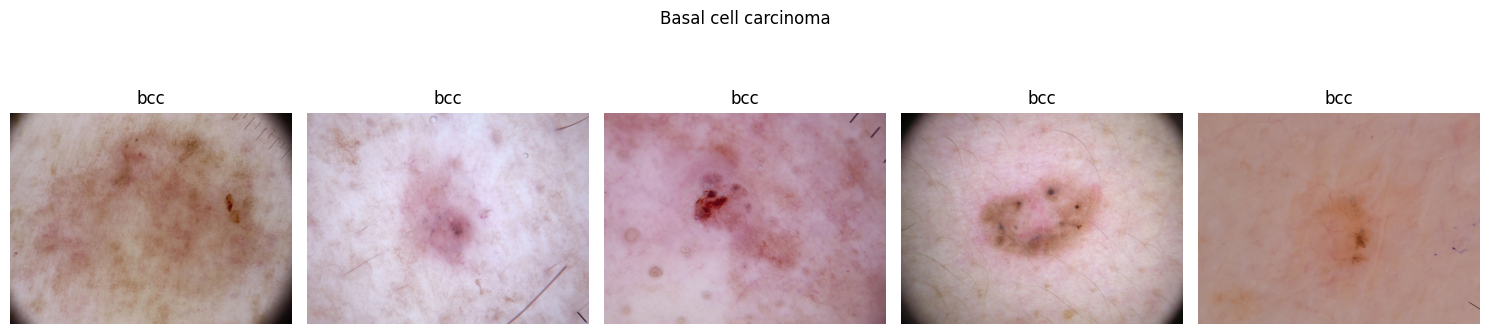

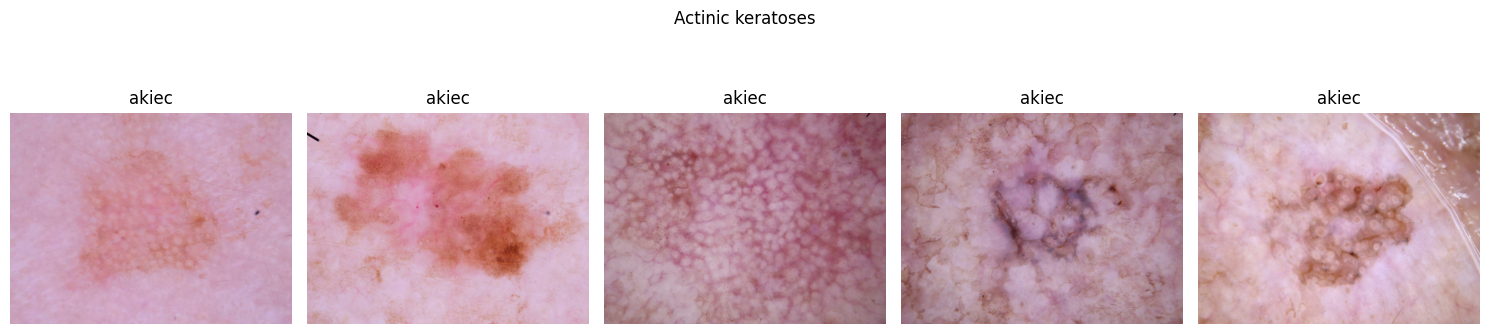

In [16]:
for diagnosis in metadata["diagnosis_full"].unique():
    display_samples(metadata, diagnosis)

## 10. Image Dimension Analysis

In [17]:
def get_image_size(path):
    with Image.open(path) as img:
        return img.size

sample_paths = metadata["image_path"].sample(200, random_state=42)

sizes = [get_image_size(path) for path in sample_paths]

sizes[:10]

[(600, 450),
 (600, 450),
 (600, 450),
 (600, 450),
 (600, 450),
 (600, 450),
 (600, 450),
 (600, 450),
 (600, 450),
 (600, 450)]

### Distribution

In [20]:
Counter(sizes)

Counter({(600, 450): 200})

## Visual Observations

Several challenges can already be observed:

- high intra-class variability
- visual similarity between some classes
- differences in lighting and contrast
- artifacts such as hair or ruler marks
- lesion size variability

These characteristics make the classification task challenging.

## Key Findings

- The dataset is strongly imbalanced
- Some lesion categories are underrepresented
- Images present important visual variability
- Metadata contains missing values
- Certain classes appear visually similar
- Robust evaluation metrics will be required